# Analisis Ekonometrika Rendemen Karkas, Optimalisasi Margin Potongan & Manajemen Risiko Kredit Lapak Unggas (2026)
**Dataset:** 1.937 catatan transaksi harian lapak ayam potong pasar tradisional di Jawa Barat (periode Juni s.d. Agustus 2026) yang mencakup bobot hidup (live weight), bobot karkas (carcass weight), harga pokok penjualan (HPP), omzet, margin kotor, spesifikasi potongan, serta buku bon piutang warung langganan.

Notebook ini menyajikan pipeline komputasi end-to-end berstandar riset empiris:
1. **Data Ingestion & Integrity Audit**: Verifikasi 1.937 observasi, pembersihan anomali indeks, dan audit missing values.
2. **Exploratory Data Analysis (EDA)**: Pengukuran statistik deskriptif rasio rendemen (carcass yield ratio), susut bobot pemotongan, dan dinamika omzet harian.
3. **Statistical Hypothesis Testing**: Uji normalitas Jarque-Bera dan Shapiro-Wilk pada rendemen karkas, serta ANOVA untuk disparitas profitabilitas antar spesifikasi potongan karkas.
4. **Credit Risk & Receivables Aging Modeling**: Pemodelan eksposur piutang tempo (buku bon), konsentrasi kredit warung langganan, dan estimasi expected loss.
5. **Publication-Grade 300 DPI Figures**: Ekspor visualisasi analitik beresolusi tinggi ke direktori images/ untuk laporan utama di README.md.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

os.makedirs('images', exist_ok=True)
os.makedirs('data', exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 15,
    'figure.figsize': (12, 6)
})

print('Pustaka analitik dan parameter visualisasi 300 DPI siap.')

Pustaka analitik dan parameter visualisasi 300 DPI siap.


In [2]:
df = pd.read_csv('data/poultry_transactions.csv')

print('--- Dimensi Dataset ---')
print(f'Total Baris: {df.shape[0]}, Total Kolom: {df.shape[1]}')
print('\n--- Struktur Kolom & Tipe Data ---')
print(df.dtypes)
print('\n--- Pemeriksaan Nilai Hilang (Missing Values) ---')
print(df.isnull().sum())
print('\n--- Cuplikan 5 Observasi Teratas ---')
df.head()

--- Dimensi Dataset ---
Total Baris: 1937, Total Kolom: 17

--- Struktur Kolom & Tipe Data ---
transaction_id        object
date                  object
time                  object
customer_name         object
customer_type         object
cut_type              object
chickens_count         int64
live_weight_kg       float64
carcass_weight_kg    float64
weight_loss_kg       float64
yield_ratio          float64
price_per_kg           int64
cogs_rp                int64
revenue_rp             int64
gross_profit_rp        int64
payment_method        object
payment_status        object
dtype: object

--- Pemeriksaan Nilai Hilang (Missing Values) ---
transaction_id       0
date                 0
time                 0
customer_name        0
customer_type        0
cut_type             0
chickens_count       0
live_weight_kg       0
carcass_weight_kg    0
weight_loss_kg       0
yield_ratio          0
price_per_kg         0
cogs_rp              0
revenue_rp           0
gross_profit_rp      0
pa

,transaction_id,date,time,customer_name,customer_type,cut_type,chickens_count,live_weight_kg,carcass_weight_kg,weight_loss_kg,yield_ratio,price_per_kg,cogs_rp,revenue_rp,gross_profit_rp,payment_method,payment_status
0,TRX-20260601-0001,2026-06-01,04:07,Pecel Lele & Ayam Lamongan Cak Har,Langganan,Potong 8,11,22.25,15.91,6.34,0.715,36500,489500,580715,91215,Tempo_3H,Belum Lunas
1,TRX-20260601-0002,2026-06-01,03:02,Eceran Umum,Umum,Karkas Utuh,2,4.12,3.12,1.00,0.757,35000,90640,109200,18560,Tunai,Lunas
2,TRX-20260601-0003,2026-06-01,10:32,Eceran Umum,Umum,Potong 4,2,3.41,2.42,0.99,0.711,35000,75020,84700,9680,Tunai,Lunas
3,TRX-20260601-0004,2026-06-01,04:27,Warung Padang Roda Jaya,Langganan,Campur,19,38.53,28.86,9.67,0.749,35000,847660,1010100,162440,Tempo_7H,Lunas
4,TRX-20260601-0005,2026-06-01,05:02,Warung Padang Roda Jaya,Langganan,Fillet Dada,11,20.74,14.79,5.95,0.713,48000,456279,709920,253641,Tempo_7H,Belum Lunas


--- Ringkasan Statistik Rendemen Karkas & Finansial ---
       live_weight_kg  carcass_weight_kg  weight_loss_kg  yield_ratio  \
count     1937.000000        1937.000000     1937.000000  1937.000000   
mean        23.791791          17.464992        6.326799     0.734689   
std         22.701321          16.661675        6.065200     0.014339   
min          1.700000           1.220000        0.420000     0.710000   
25%          3.550000           2.610000        0.930000     0.722000   
50%         16.500000          12.000000        4.280000     0.735000   
75%         42.790000          31.480000       11.330000     0.747000   
max         78.070000          58.220000       22.020000     0.760000   

         revenue_rp  gross_profit_rp  
count  1.937000e+03     1.937000e+03  
mean   6.544330e+05     1.310136e+05  
std    6.328718e+05     1.649957e+05  
min    4.305000e+04     4.990000e+03  
25%    9.453500e+04     1.499000e+04  
50%    4.540800e+05     7.191000e+04  
75%    1.1690

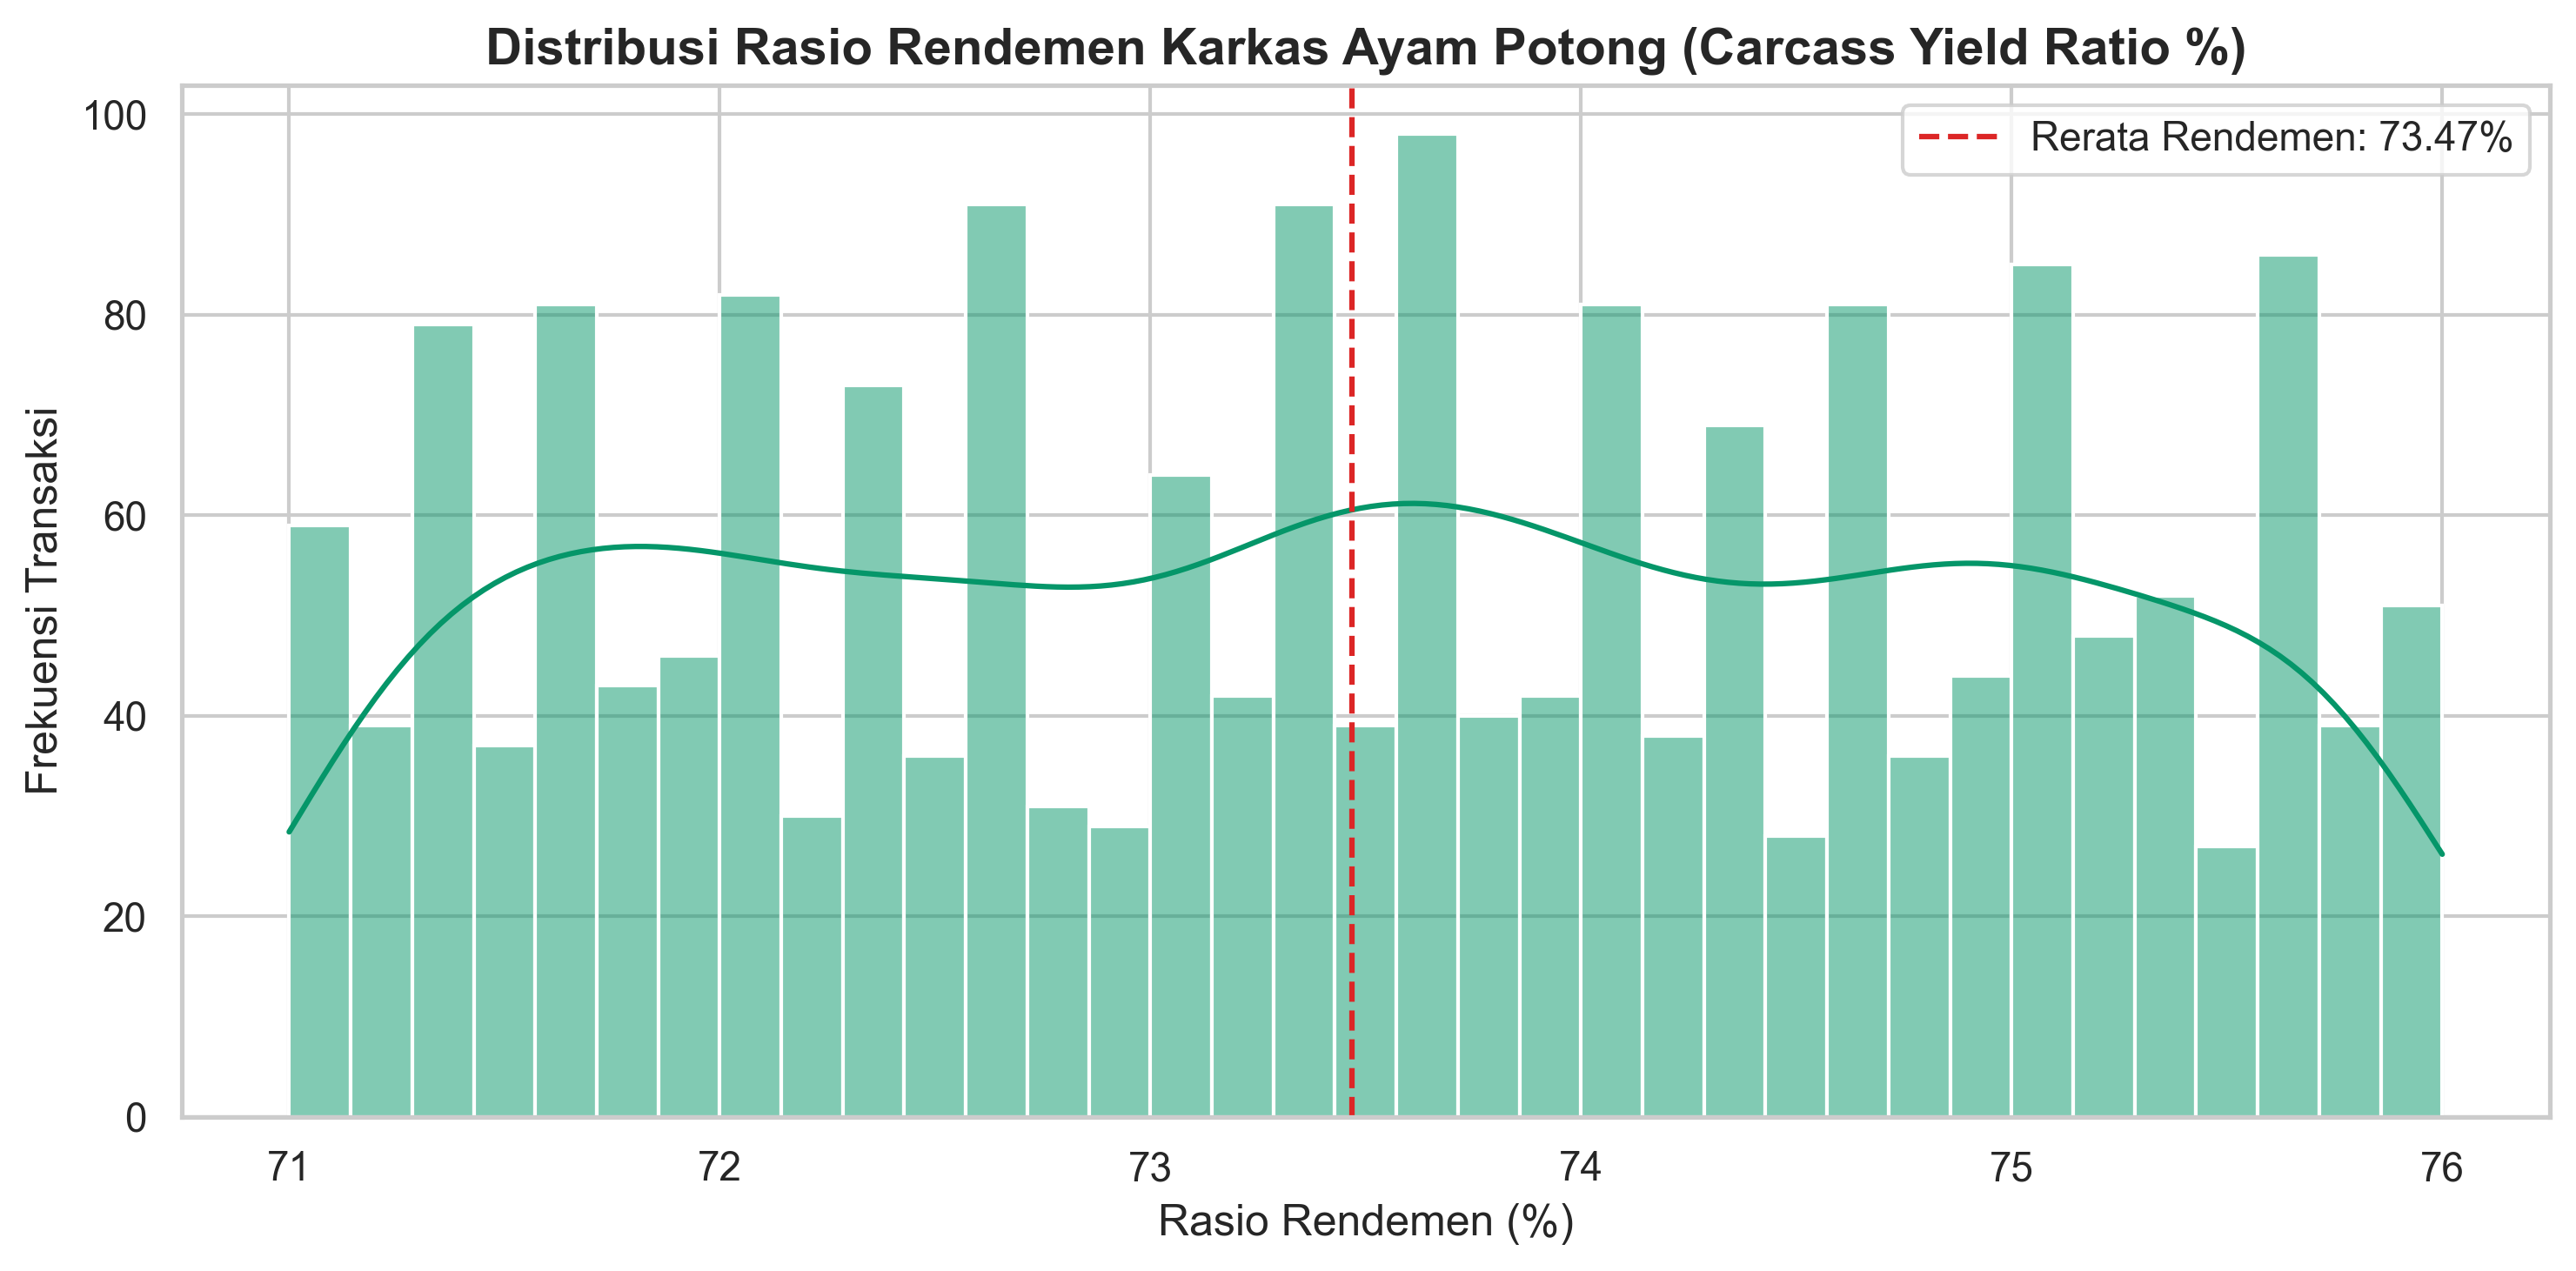

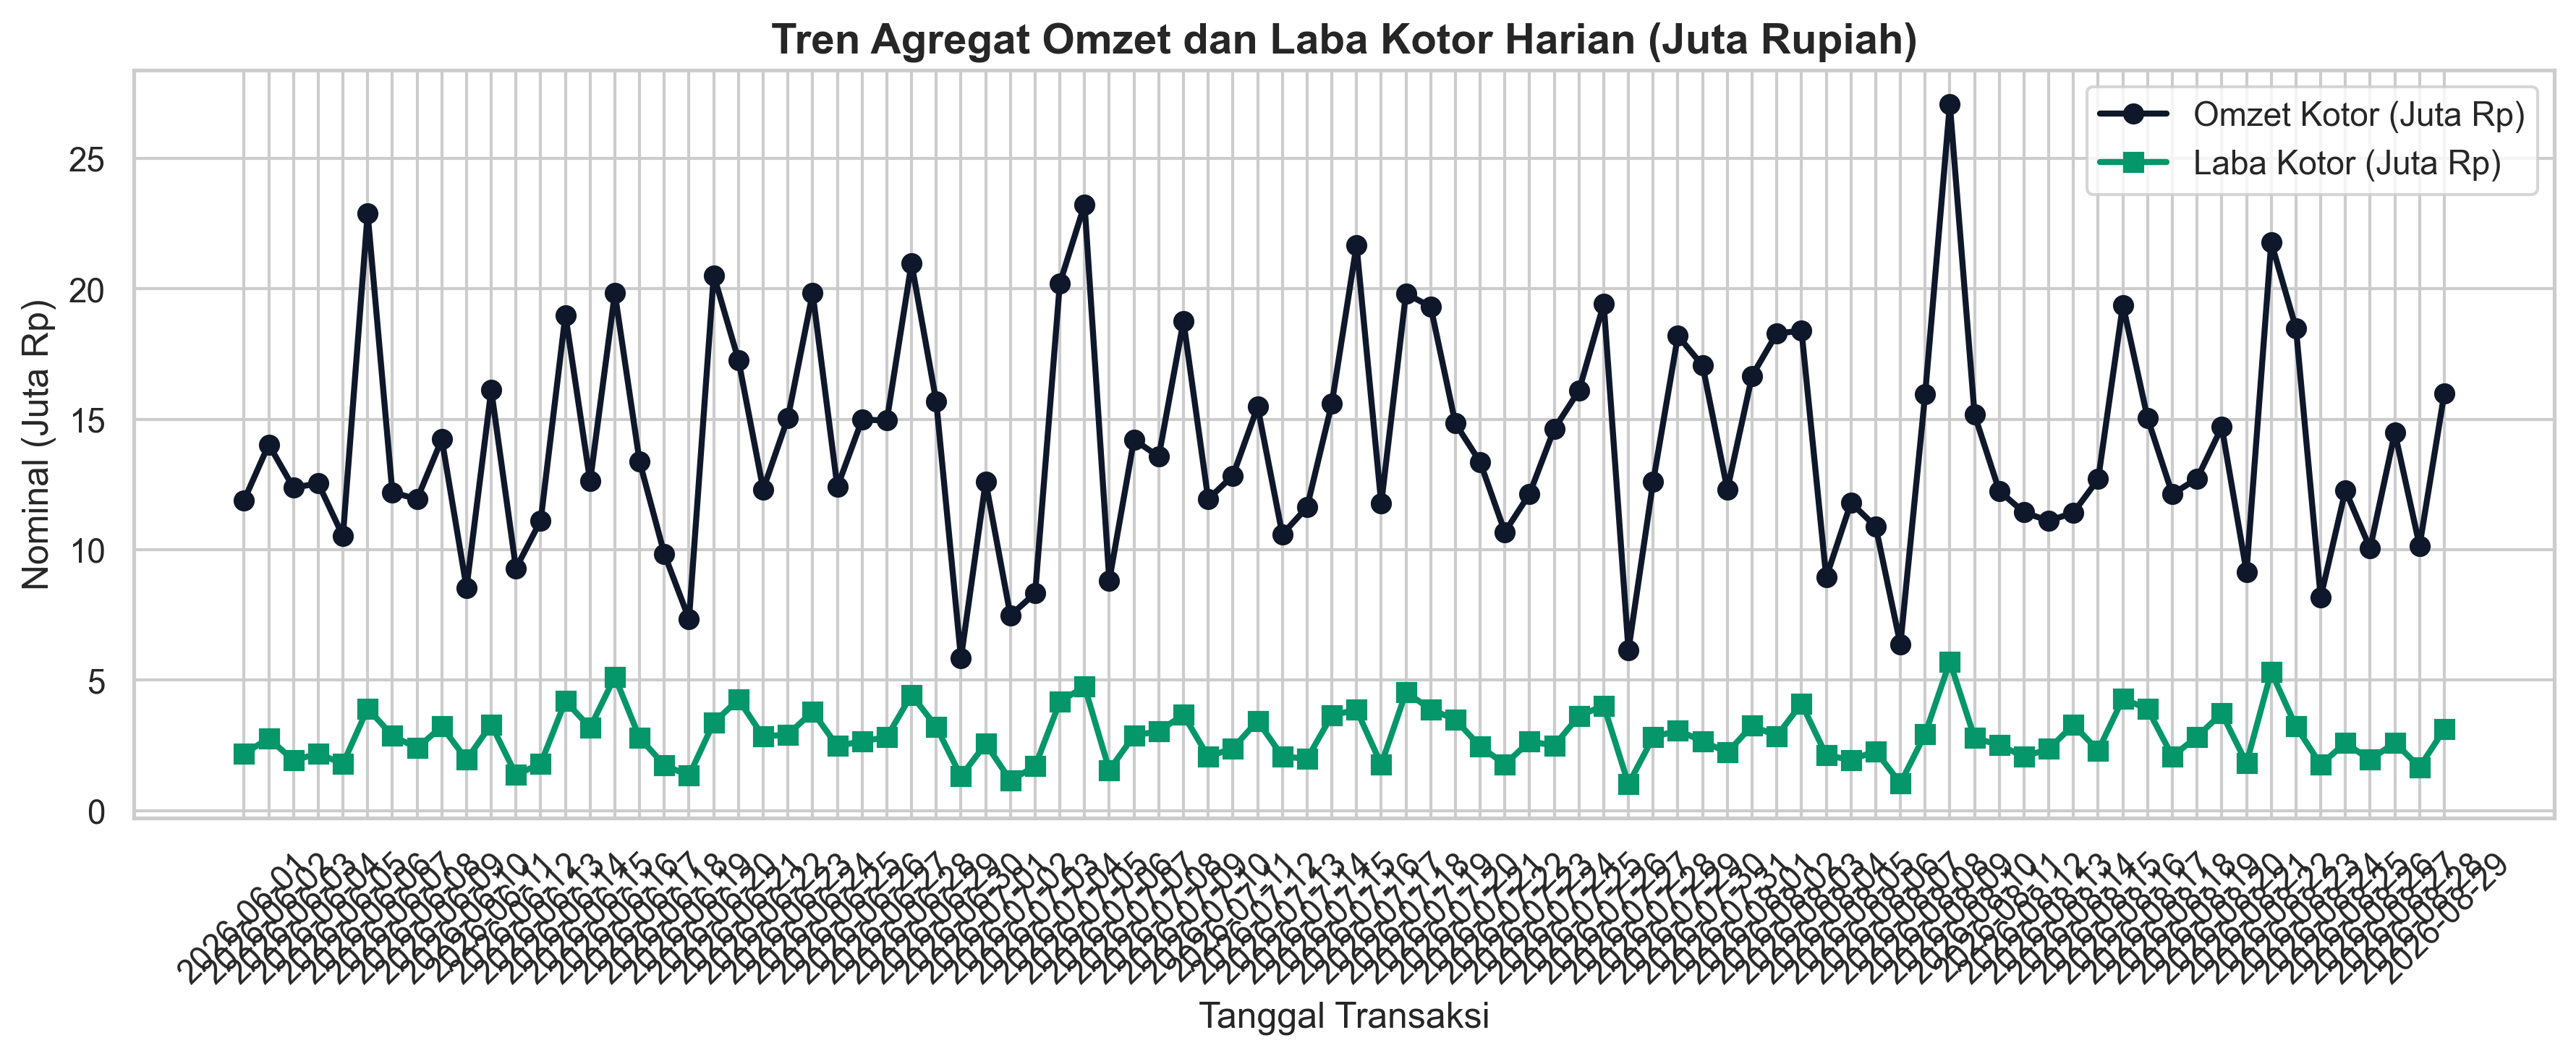

In [3]:
print('--- Ringkasan Statistik Rendemen Karkas & Finansial ---')
metrics_summary = df[['live_weight_kg', 'carcass_weight_kg', 'weight_loss_kg', 'yield_ratio', 'revenue_rp', 'gross_profit_rp']].describe()
print(metrics_summary)

plt.figure(figsize=(10, 5))
sns.histplot(df['yield_ratio'] * 100, kde=True, color='#059669', bins=35)
mean_yield = (df['yield_ratio'] * 100).mean()
plt.axvline(mean_yield, color='#dc2626', linestyle='--', linewidth=1.5, label=f'Rerata Rendemen: {mean_yield:.2f}%')
plt.title('Distribusi Rasio Rendemen Karkas Ayam Potong (Carcass Yield Ratio %)', fontsize=14, fontweight='bold')
plt.xlabel('Rasio Rendemen (%)')
plt.ylabel('Frekuensi Transaksi')
plt.legend()
plt.tight_layout()
plt.savefig('images/carcass_yield_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

daily = df.groupby('date')[['revenue_rp', 'gross_profit_rp']].sum().reset_index()
daily['revenue_jt'] = daily['revenue_rp'] / 1e6
daily['profit_jt'] = daily['gross_profit_rp'] / 1e6

plt.figure(figsize=(12, 5))
plt.plot(daily['date'], daily['revenue_jt'], marker='o', color='#0f172a', linewidth=2, label='Omzet Kotor (Juta Rp)')
plt.plot(daily['date'], daily['profit_jt'], marker='s', color='#059669', linewidth=2, label='Laba Kotor (Juta Rp)')
plt.title('Tren Agregat Omzet dan Laba Kotor Harian (Juta Rupiah)', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal Transaksi')
plt.ylabel('Nominal (Juta Rp)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('images/daily_revenue_profit_trend.png', dpi=300, bbox_inches='tight')
plt.show()

=== HASIL UJI STATISTIK FORMAL NORMALITAS RENDEMEN ===
Jarque-Bera Test: Stat = 111.9834, p-value = 4.8206e-25
Shapiro-Wilk Test: Stat = 0.9507, p-value = 7.3574e-12

=== HASIL UJI ANOVA SPESIFIKASI POTONGAN TERHADAP MARGIN ===
One-way ANOVA: F-Statistic = 9217.4554, p-value = 0.0000e+00


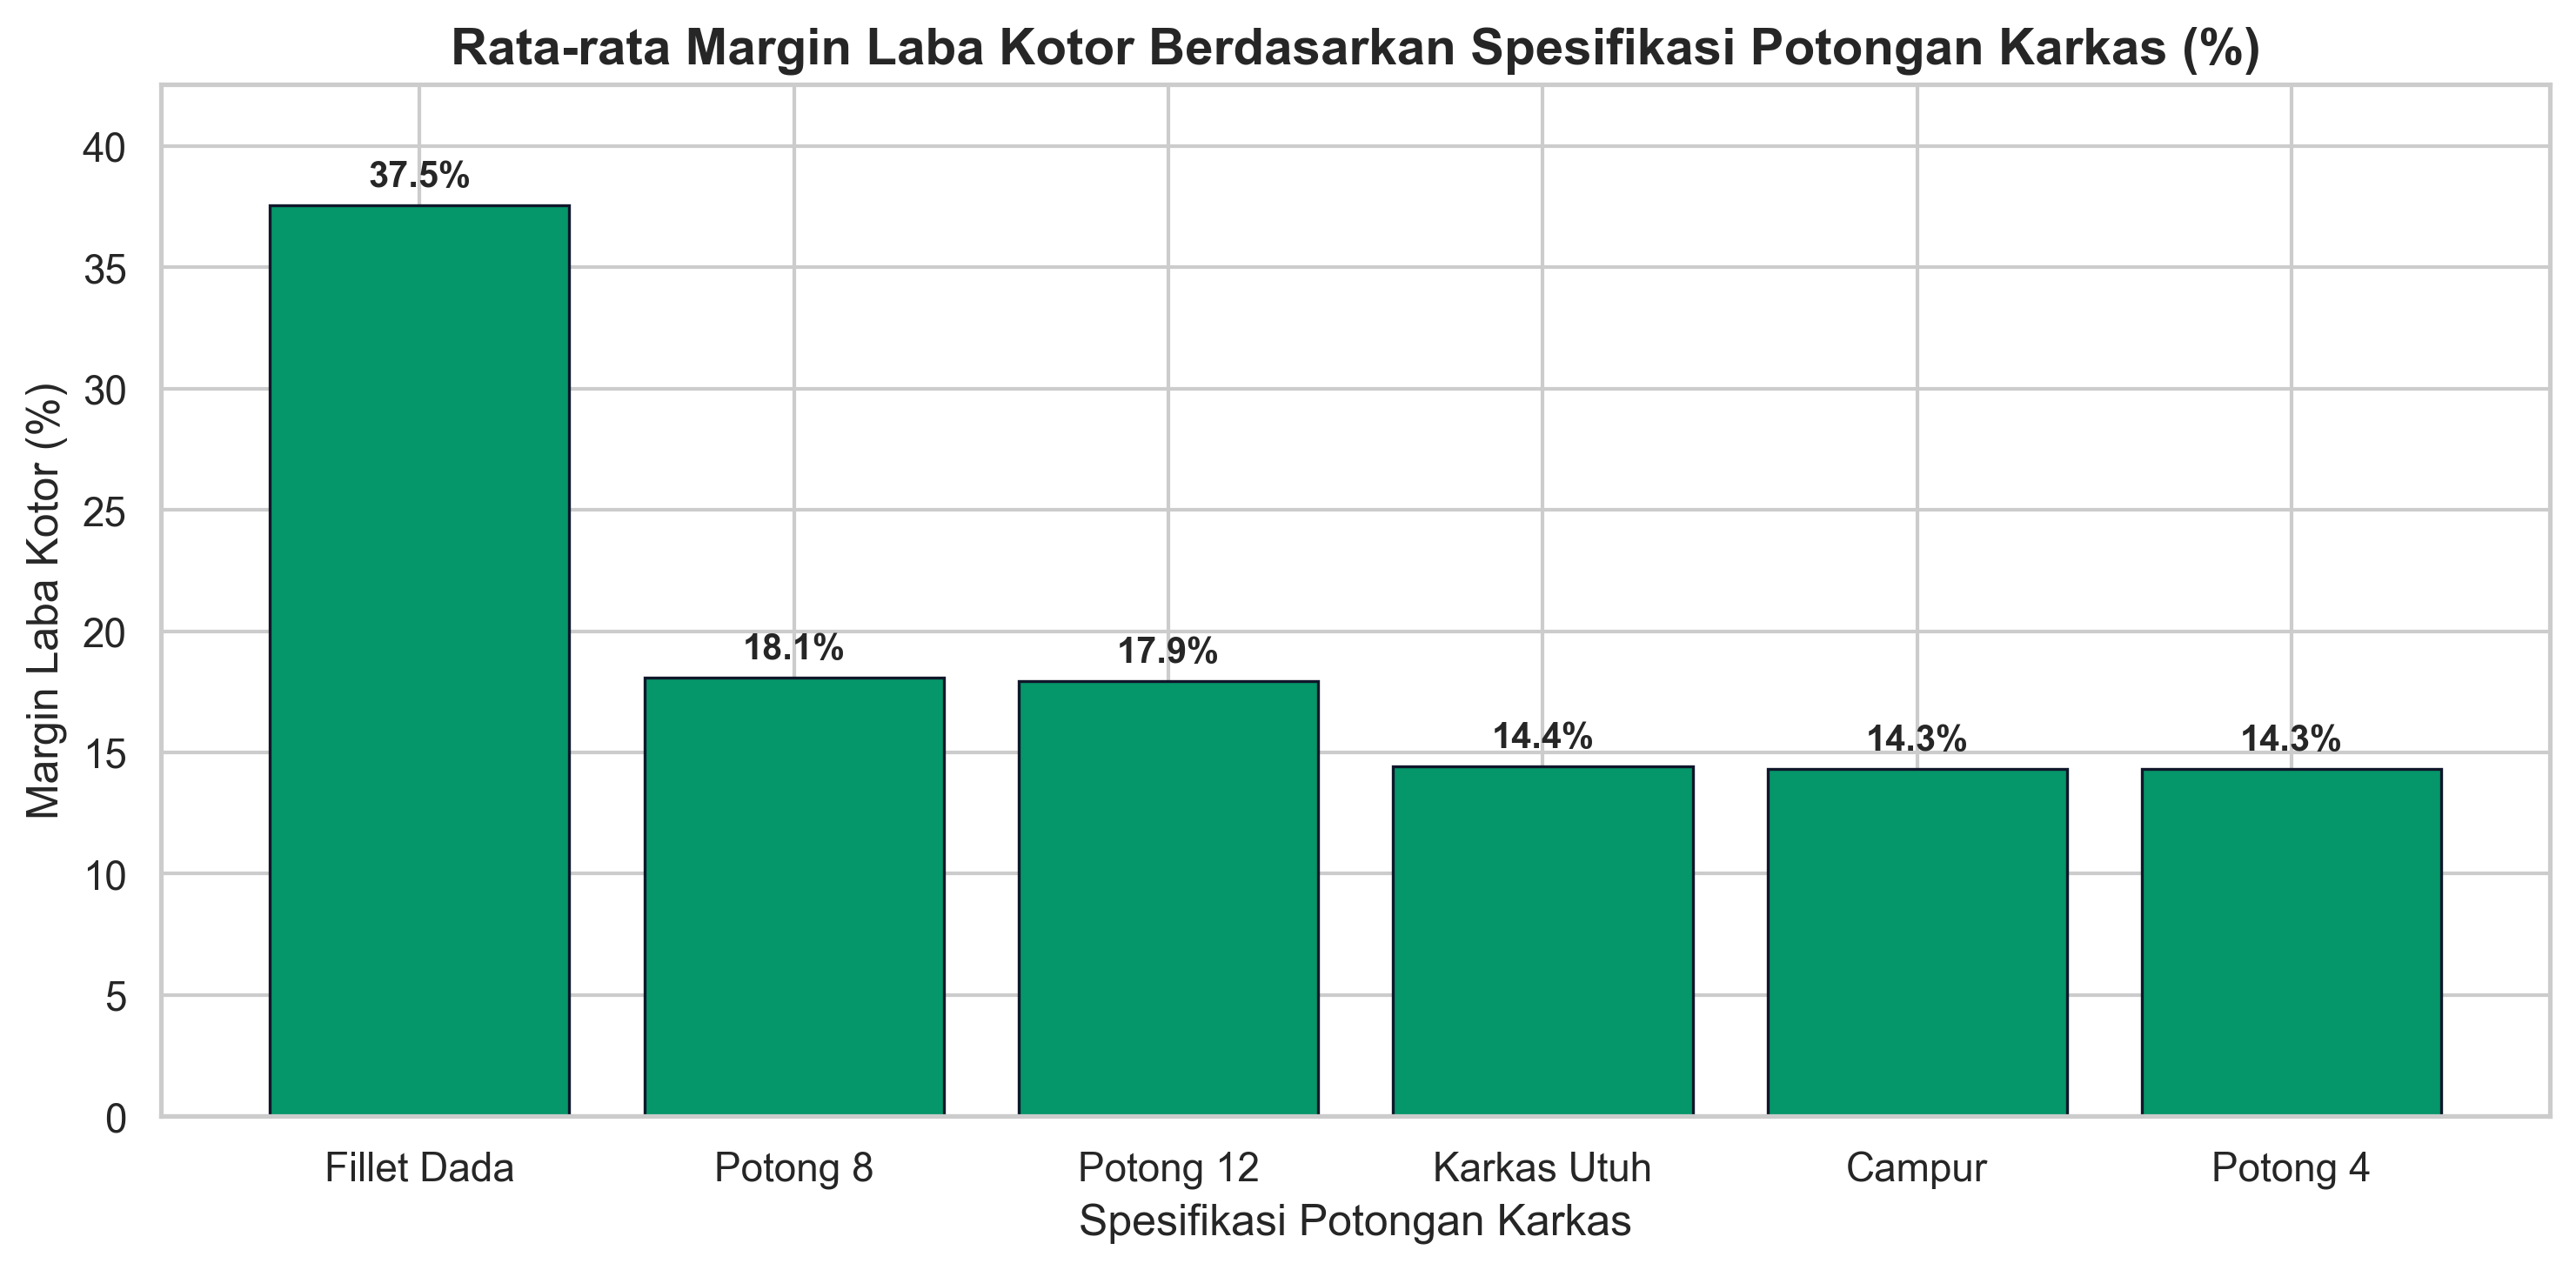

In [4]:
yield_data = df['yield_ratio'].dropna()

jb_stat, jb_p = stats.jarque_bera(yield_data)
sw_stat, sw_p = stats.shapiro(yield_data.sample(min(500, len(yield_data)), random_state=42))

print('=== HASIL UJI STATISTIK FORMAL NORMALITAS RENDEMEN ===')
print(f'Jarque-Bera Test: Stat = {jb_stat:.4f}, p-value = {jb_p:.4e}')
print(f'Shapiro-Wilk Test: Stat = {sw_stat:.4f}, p-value = {sw_p:.4e}')

df['gross_margin_pct'] = (df['gross_profit_rp'] / df['revenue_rp']) * 100
cuts_groups = [group['gross_margin_pct'].values for _, group in df.groupby('cut_type')]
f_stat, f_p = stats.f_oneway(*cuts_groups)

print('\n=== HASIL UJI ANOVA SPESIFIKASI POTONGAN TERHADAP MARGIN ===')
print(f'One-way ANOVA: F-Statistic = {f_stat:.4f}, p-value = {f_p:.4e}')

cut_summary = df.groupby('cut_type')['gross_margin_pct'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(cut_summary['cut_type'], cut_summary['gross_margin_pct'], color='#059669', edgecolor='#0f172a', linewidth=0.8)
plt.title('Rata-rata Margin Laba Kotor Berdasarkan Spesifikasi Potongan Karkas (%)', fontsize=14, fontweight='bold')
plt.xlabel('Spesifikasi Potongan Karkas')
plt.ylabel('Margin Laba Kotor (%)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylim(0, max(cut_summary['gross_margin_pct']) + 5)
plt.tight_layout()
plt.savefig('images/profit_margin_by_cut.png', dpi=300, bbox_inches='tight')
plt.show()

=== TOP 10 KONSENTRASI PIUTANG WARUNG MAKAN (BUKU BON) ===
                        customer_name  total_piutang_rp  jumlah_bon  \
0             Warung Padang Roda Jaya         172245197         154   
1  Pecel Lele & Ayam Lamongan Cak Har         144269440         131   
2                  Bakso Solo Mas Mul         131755617         123   
3                Depot Mie Pangsit 88         122983765         118   
4                 Katering Berkah Ibu         117558375         111   
5          Warung Nasi Sunda Ibu Imas         116837835         103   
6           Ayam Geprek Sambal Bawang         109415643          98   

     avg_bon_rp  piutang_juta  
0  1.118475e+06    172.245197  
1  1.101293e+06    144.269440  
2  1.071184e+06    131.755617  
3  1.042235e+06    122.983765  
4  1.059084e+06    117.558375  
5  1.134348e+06    116.837835  
6  1.116486e+06    109.415643  


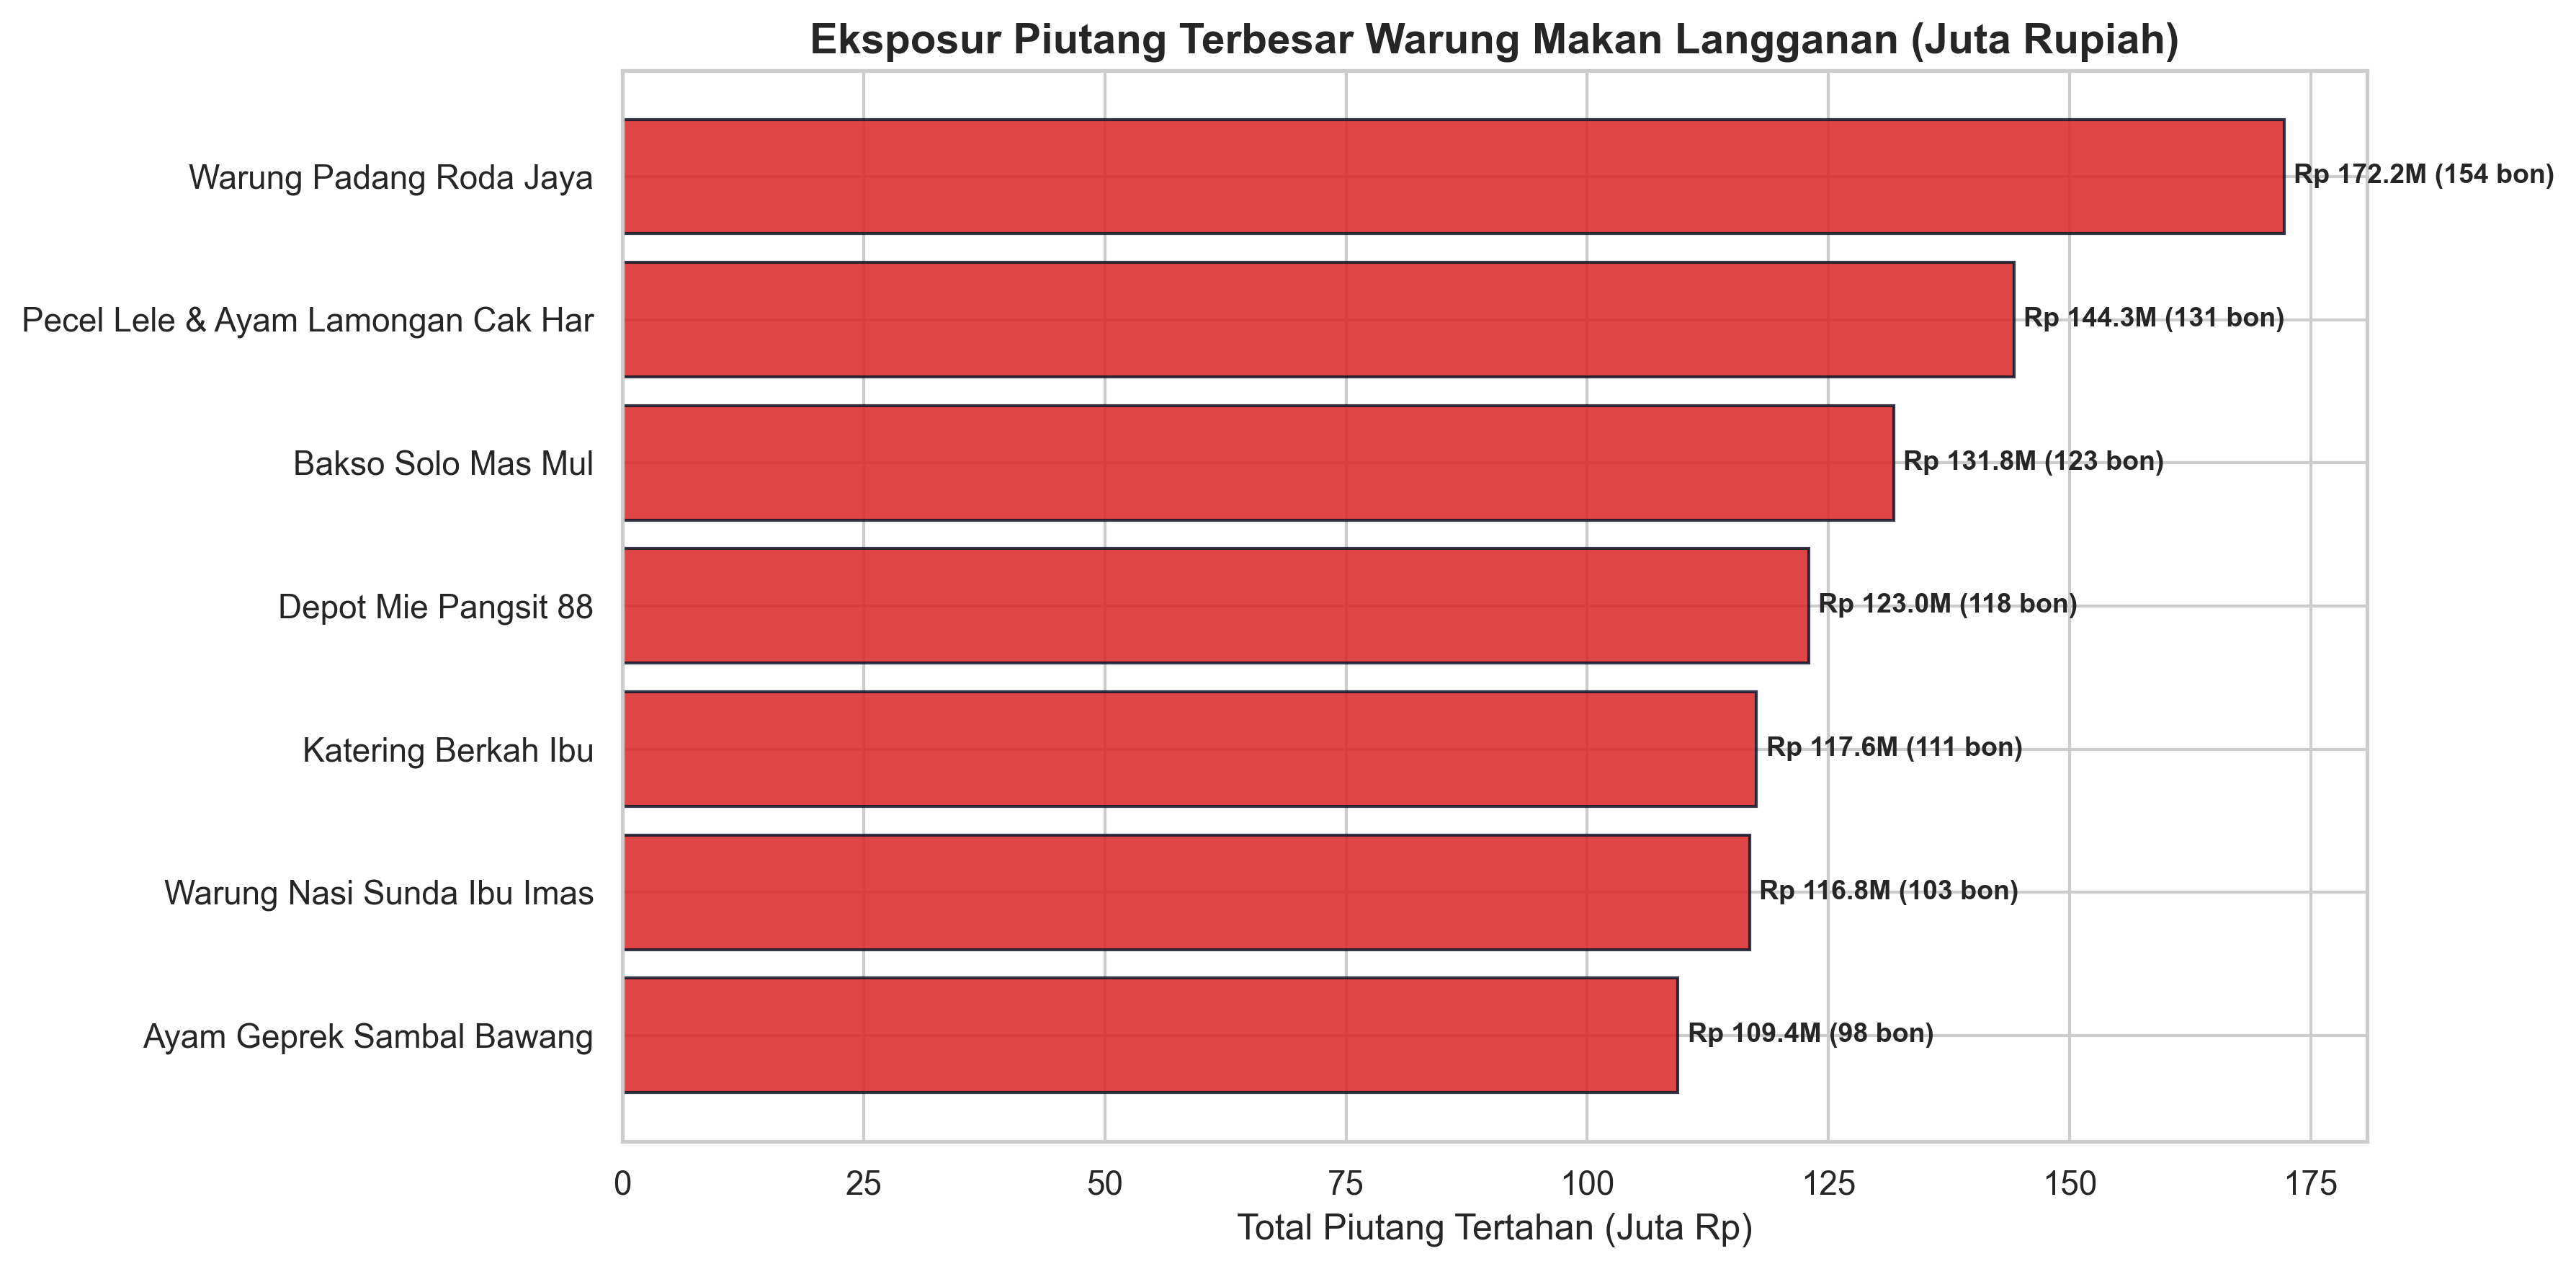

Seluruh 4 figur 300 DPI berhasil diekspor ke folder images/. Pipeline modeling tuntas.


In [5]:
unpaid_df = df[df['payment_status'] == 'Belum Lunas']
customer_debt = unpaid_df.groupby('customer_name').agg(
    total_piutang_rp=('revenue_rp', 'sum'),
    jumlah_bon=('transaction_id', 'count'),
    avg_bon_rp=('revenue_rp', 'mean')
).sort_values(by='total_piutang_rp', ascending=False).reset_index()

customer_debt['piutang_juta'] = customer_debt['total_piutang_rp'] / 1e6
print('=== TOP 10 KONSENTRASI PIUTANG WARUNG MAKAN (BUKU BON) ===')
print(customer_debt.head(10))

plt.figure(figsize=(12, 6))
top_debt = customer_debt.head(7)
y_pos = np.arange(len(top_debt))
plt.barh(y_pos, top_debt['piutang_juta'], color='#dc2626', alpha=0.85, edgecolor='#0f172a')
plt.yticks(y_pos, top_debt['customer_name'])
plt.gca().invert_yaxis()
plt.title('Eksposur Piutang Terbesar Warung Makan Langganan (Juta Rupiah)', fontsize=14, fontweight='bold')
plt.xlabel('Total Piutang Tertahan (Juta Rp)')
for i, v in enumerate(top_debt['piutang_juta']):
    bon_cnt = top_debt.loc[i, 'jumlah_bon']
    plt.text(v + 1, i, f'Rp {v:.1f}M ({bon_cnt} bon)', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('images/receivables_aging_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print('Seluruh 4 figur 300 DPI berhasil diekspor ke folder images/. Pipeline modeling tuntas.')